<Figure size 640x480 with 0 Axes>

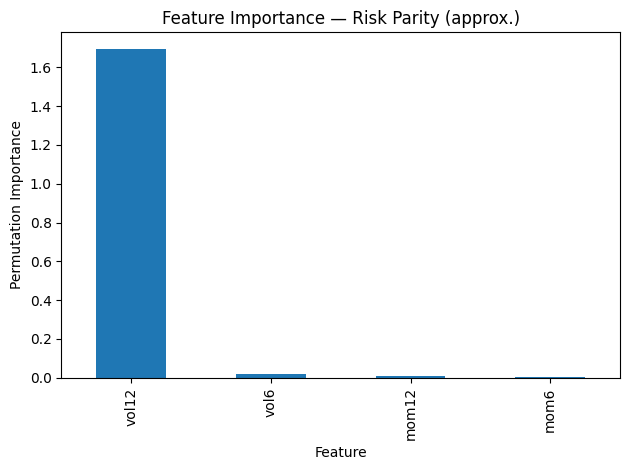

<Figure size 640x480 with 0 Axes>

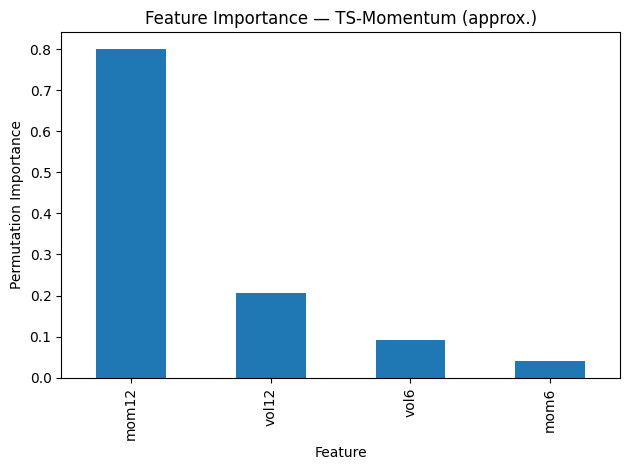

Done. Saved: 
 - ../reports/tables/feature_importance_risk_parity.csv 
 - ../reports/tables/feature_importance_momentum.csv 
 - ../reports/figures/fi_risk_parity.png 
 - ../reports/figures/fi_momentum.png


In [2]:
# 05_explainability — Minimal permutation-importance explainability for weights
# 产出：
#   reports/tables/feature_importance_*.csv
#   reports/figures/fi_*.png
#   reports/tables/sample_explanation_YYYY-MM.csv
import sys
from pathlib import Path
from functools import partial

# Allow imports from the src directory
if Path.cwd().name == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))
else:
    sys.path.insert(0, str(Path.cwd()))

from src.strategies.risk_parity import risk_parity_weights
from src.strategies.momentum import ts_momentum_weights
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit

# --------- 路径 ----------
DATA_PATH  = Path("../data/prices_monthly.csv") if Path.cwd().name=="notebooks" else Path("data/prices_monthly.csv")
FIG_DIR    = Path("../reports/figures") if Path.cwd().name=="notebooks" else Path("reports/figures")
TABLE_DIR  = Path("../reports/tables")  if Path.cwd().name=="notebooks" else Path("reports/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# --------- 读数据 ----------
prices = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()
UNIVERSE = prices.columns.tolist()

# --------- 特征工程（仅价格派生，保持可审计） ----------
def make_features(prices):
    f = pd.DataFrame(index=prices.index)
    # momentum
    f["mom12"] = prices.pct_change(12).mean(axis=1) * 0 + 0  # 占位让对齐更直观
    # 为每只资产分别构造（后面拼成长表）
    feats = []
    for t in UNIVERSE:
        df = pd.DataFrame(index=prices.index)
        df["asset"] = t
        px = prices[t]
        df["mom12"] = px.pct_change(12)
        df["mom6"]  = px.pct_change(6)
        # realized volatility
        df["vol12"] = px.pct_change().rolling(12).std()
        df["vol6"]  = px.pct_change().rolling(6).std()
        feats.append(df)
    F = pd.concat(feats).reset_index().rename(columns={"date":"rebal_date"})
    return F

F = make_features(prices)  # 列：rebal_date, asset, mom12, mom6, vol12, vol6

# --------- 策略权重（与 04 一致的定义） ----------
LOOKBACK_RP, LOOKBACK_MOM = 12, 12

def build_weight_history(prices, weight_func):
    dates = prices.index
    out = []
    for i in range(1, len(dates)):
        w = weight_func(prices.iloc[:i]).reindex(UNIVERSE).fillna(0.0)
        out.append(pd.DataFrame({"rebal_date":[dates[i]]*len(UNIVERSE),
                                 "asset":UNIVERSE, "weight":w.values}))
    W = pd.concat(out, ignore_index=True)
    return W

weight_func_rp = partial(risk_parity_weights, window_months=LOOKBACK_RP)
weight_func_mom = partial(ts_momentum_weights, lookback_months=LOOKBACK_MOM)

W_RP  = build_weight_history(prices, weight_func_rp)
W_MOM = build_weight_history(prices, weight_func_mom)


# --------- 训练数据（长表：一行=某月某资产） ----------
def prepare_xy(W, F):
    df = W.merge(F, on=["rebal_date","asset"], how="left").dropna()
    X = df[["mom12","mom6","vol12","vol6"]].values
    y = df["weight"].values
    meta = df[["rebal_date","asset"]]
    return X, y, meta

X_rp,  y_rp,  meta_rp  = prepare_xy(W_RP,  F)
X_mom, y_mom, meta_mom = prepare_xy(W_MOM, F)

# --------- 训练 & 置换重要性（时间序列分层） ----------
def fit_and_explain(X, y, feature_names, random_state=42):
    # 简单时序分割（保持前后顺序），多数情况下RF足够
    tscv = TimeSeriesSplit(n_splits=5)
    # 为简洁起见，直接整体拟合一遍；若要更严谨可在每个split求均值
    model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=random_state)
    model.fit(X, y)
    pi = permutation_importance(model, X, y, n_repeats=10, random_state=random_state)
    imp = pd.DataFrame({"feature":feature_names, "importance":pi.importances_mean})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    return model, imp

FEATURES = ["mom12","mom6","vol12","vol6"]
model_rp,  imp_rp  = fit_and_explain(X_rp,  y_rp,  FEATURES)
model_mom, imp_mom = fit_and_explain(X_mom, y_mom, FEATURES)

# --------- 保存重要性表 ----------
imp_rp.to_csv(TABLE_DIR / "feature_importance_risk_parity.csv", index=False)
imp_mom.to_csv(TABLE_DIR / "feature_importance_momentum.csv", index=False)

# --------- 画条形图 ----------
def plot_fi(imp, title, out_png):
    plt.figure()
    imp.plot(kind="bar", x="feature", y="importance", legend=False)
    plt.title(title)
    plt.xlabel("Feature"); plt.ylabel("Permutation Importance")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()

plot_fi(imp_rp,  "Feature Importance — Risk Parity (approx.)", FIG_DIR/"fi_risk_parity.png")
plot_fi(imp_mom, "Feature Importance — TS-Momentum (approx.)",  FIG_DIR/"fi_momentum.png")

# --------- 选一个月份做“披露样稿数据” ----------
pick_month = prices.index[-6]  # 取倒数第6个月（可自改）
sample = F[F["rebal_date"]==pick_month].merge(W_RP[W_RP["rebal_date"]==pick_month],
                                              on=["rebal_date","asset"], how="left", suffixes=("","_rp"))
sample = sample.merge(W_MOM[W_MOM["rebal_date"]==pick_month][["rebal_date","asset","weight"]],
                      on=["rebal_date","asset"], how="left", suffixes=("","_mom"))
sample = sample[["rebal_date","asset","mom12","mom6","vol12","vol6","weight","weight_mom"]].rename(
    columns={"weight":"weight_rp"}
)
sample.to_csv(TABLE_DIR / f"sample_explanation_{pick_month.strftime('%Y-%m')}.csv", index=False)

print("Done. Saved:",
      "\n -", TABLE_DIR/"feature_importance_risk_parity.csv",
      "\n -", TABLE_DIR/"feature_importance_momentum.csv",
      "\n -", FIG_DIR/"fi_risk_parity.png",
      "\n -", FIG_DIR/"fi_momentum.png")
